In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import warnings
warnings.filterwarnings('ignore')

In [2]:
# NOTE:
# If you encounter any issues importing the customer_churn.db file,
# run the code below to create the database locally from the provided Excel file OR, can directly import data & start working.

# Otherwise, skip this step and proceed to the next section: Data Import

# Excel file path
excel_file = 'customer_churn_data_raw.xlsx'

# Create SQLite database connection
conn = sqlite3.connect('customer_churn.db')

# Read all sheet names from Excel file
excel_data = pd.ExcelFile(excel_file)

# Loop through each sheet and store as separate table
for sheet in excel_data.sheet_names:
    df = pd.read_excel(excel_file, sheet_name=sheet) # Read sheet into dataframe
    # Write dataframe to SQLite table
    df.to_sql(
        name=sheet,          # Table name = Sheet name
        con=conn,
        if_exists='replace', # Replace table if already exists
        index=False
    )

# Close connection
conn.close()

print("All sheets successfully converted into SQLite tables.")

All sheets successfully converted into SQLite tables.


In [3]:
# Data Import: db file to pandas, storing each table to a separate df

# Connect to SQLite database
conn = sqlite3.connect('customer_churn.db')

# sql query to Get all table names
sql_query = """
        SELECT name
        FROM sqlite_master
        WHERE type='table';
"""

# read sql query in pandas
tables = pd.read_sql(sql_query, conn)

# create dataframe for each table
for table_name in tables['name']:
    df = pd.read_sql(f"SELECT * FROM {table_name}", conn) # Read table into dataframe
    globals()[f"df_{table_name}"] = df                    # Create dynamic dataframe name
    print(f"Created dataframe: df_{table_name}")

# Close connection
conn.close()

Created dataframe: df_db_customer
Created dataframe: df_db_subscription
Created dataframe: df_db_support


In [4]:
# Print table names and column names
conn = sqlite3.connect('customer_churn.db')

for table_name in tables['name']:
    print(f"\nTable Name: {table_name}")
    # Get column information
    columns_query = f"PRAGMA table_info({table_name});"
    columns = pd.read_sql(columns_query, conn)
    print("Columns:")
    print(columns['name'].tolist())

# Close connection
conn.close()


Table Name: db_customer
Columns:
['customerid', 'name', 'country', 'state', 'gender', 'dob', 'interests', 'pincode']

Table Name: db_subscription
Columns:
['customerid', 'subscription_start_date', 'subscription_type', 'renewal_date', 'plan_type', 'contract_type', 'cancellation_date', 'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score']

Table Name: db_support
Columns:
['customerid', 'complaint_date', 'escalations', 'csat_score', 'col_1', 'comment']


# **1. Data cleaning**





# *df_db_customer*

In [5]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [6]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerid  21 non-null     object
 1   name        21 non-null     object
 2   country     18 non-null     object
 3   state       21 non-null     object
 4   gender      21 non-null     object
 5   dob         21 non-null     object
 6   interests   4 non-null      object
 7   pincode     0 non-null      object
dtypes: object(8)
memory usage: 1.4+ KB


In [7]:
df_db_customer.shape

(21, 8)

In [8]:
df_db_customer.describe()

,customerid,name,country,state,gender,dob,interests,pincode
count,21,21,18,21,21,21,4,0
unique,21,21,2,9,4,21,4,0
top,0002-ORFBO,keshav,India,Delhi,Female,1982-04-12 00:00:00,travel,NaN
freq,1,1,17,4,9,1,1,NaN


In [ ]:
#a. rename column- name
#b. drop column - intrest and pincode
#c. change datatype - dob
#d. data standardisation - gender
#e. fix missing values - country

In [9]:
df_db_customer.head()

,customerid,name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [10]:
#a. rename column- name

df_db_customer.rename(columns={'name' : 'customer_name'}, inplace = True)
df_db_customer.head()

,customerid,customer_name,country,state,gender,dob,interests,pincode
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12 00:00:00,travel,None
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23 00:00:00,None,None
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15 00:00:00,movie,None
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30 00:00:00,None,None
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05 00:00:00,drama,None


In [11]:
#b. drop column - intrest and pincode

df_db_customer.drop(columns = ['interests', 'pincode'], inplace = True)


In [14]:
df_db_customer.head()


,customerid,customer_name,country,state,gender,dob
0,0002-ORFBO,keshav,India,Maharashtra,Male,1982-04-12
1,0003-MKNFE,raghav,India,Karnataka,Male,1995-11-23
2,0004-TLHLJ,lalita,India,Delhi,Female,1978-02-15
3,0011-IGKFF,mohan,India,Nagaland,Male,2001-08-30
4,0013-EXCHZ,mira,India,Delhi,Female,1990-05-05


In [15]:
#c. change datatype - dob

df_db_customer['dob'] = pd.to_datetime(df_db_customer['dob'])
df_db_customer.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        18 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


In [16]:
#d. data standardisation - gender

df_db_customer['gender'].unique()

df_db_customer['gender'] = df_db_customer['gender'].replace({'Men' : 'Male', 'Women' : 'Female'})
df_db_customer.tail()

,customerid,customer_name,country,state,gender,dob
16,0020-JDNXP,rikim,India,Meghalaya,Female,1994-08-19
17,0021-IKXGC,vishakha,India,Rajasthan,Female,2000-09-02
18,0022-TCJCI,raghvendra,India,Telangana,Male,1983-12-30
19,0023-HGHWL,rishabh,India,Uttar Pradesh,Male,1991-05-14
20,0023-UYUPN,sudevi,India,Maharashtra,Female,1977-10-06


In [17]:
#e. fix missing values - country

df_db_customer[df_db_customer['country'].isna()]



,customerid,customer_name,country,state,gender,dob
5,0013-MHZWF,durga,None,Delhi,Female,1988-12-10
8,0015-UOCOJ,maya,None,Kathmandu,Female,1985-07-07
12,0018-NYROU,chitra,None,Telangana,Female,2004-12-01


In [18]:
# country and state - unique value pair (fill na values by mapping)

state_country_mapping = df_db_customer.dropna(subset=['country']).set_index('state')['country'].to_dict()

df_db_customer['country'] = df_db_customer['country'].fillna(df_db_customer['state'].map(state_country_mapping))


In [19]:
df_db_customer[df_db_customer['country'].isna()]

,customerid,customer_name,country,state,gender,dob


In [20]:
df_db_customer[['country', 'state']]

,country,state
0,India,Maharashtra
1,India,Karnataka
2,India,Delhi
3,India,Nagaland
4,India,Delhi
5,India,Delhi
6,India,Meghalaya
7,India,Rajasthan
8,Nepal,Kathmandu
9,Nepal,Kathmandu


In [21]:
df_db_customer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   customerid     21 non-null     object        
 1   customer_name  21 non-null     object        
 2   country        21 non-null     object        
 3   state          21 non-null     object        
 4   gender         21 non-null     object        
 5   dob            21 non-null     datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 1.1+ KB


# *df_db_subscription*

In [22]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,None,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,None,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,None,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [23]:
date_col = ['subscription_start_date', 'renewal_date', 'cancellation_date']
df_db_subscription[date_col] = df_db_subscription[date_col].apply(pd.to_datetime)

In [24]:
df_db_subscription.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype         
---  ------                   --------------  -----         
 0   customerid               21 non-null     object        
 1   subscription_start_date  21 non-null     datetime64[ns]
 2   subscription_type        21 non-null     object        
 3   renewal_date             21 non-null     datetime64[ns]
 4   plan_type                21 non-null     object        
 5   contract_type            21 non-null     object        
 6   cancellation_date        6 non-null      datetime64[ns]
 7   cancellation_reason      6 non-null      object        
 8   monthly_charges          21 non-null     float64       
 9   cltv                     21 non-null     int64         
 10  churn_score              21 non-null     int64         
dtypes: datetime64[ns](3), float64(1), int64(2), object(5)
memory usage: 1.9+ KB


# *df_db_support*

In [25]:
df_db_support.head()

,customerid,complaint_date,escalations,csat_score,col_1,comment
0,0003-MKNFE,2024-08-28 00:00:00,N,60,None,service issue
1,0003-MKNFE,2024-08-28 00:00:00,Y,10,None,demaned refund
2,0013-EXCHZ,2024-01-20 00:00:00,Y,20,None,None
3,0013-MHZWF,2025-03-18 00:00:00,N,90,None,guidance to renew
4,0013-SMEOE,2024-11-01 00:00:00,N,30,None,None


In [26]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
 4   col_1           0 non-null      object
 5   comment         4 non-null      object
dtypes: int64(1), object(5)
memory usage: 564.0+ bytes


In [27]:
df_db_support.drop(columns = ['col_1', 'comment'], inplace = True)

In [28]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   customerid      9 non-null      object
 1   complaint_date  9 non-null      object
 2   escalations     9 non-null      object
 3   csat_score      9 non-null      int64 
dtypes: int64(1), object(3)
memory usage: 420.0+ bytes


In [29]:

df_db_support['complaint_date'] = pd.to_datetime(df_db_support['complaint_date'])

In [30]:
df_db_support.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9 entries, 0 to 8
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   customerid      9 non-null      object        
 1   complaint_date  9 non-null      datetime64[ns]
 2   escalations     9 non-null      object        
 3   csat_score      9 non-null      int64         
dtypes: datetime64[ns](1), int64(1), object(2)
memory usage: 420.0+ bytes


# 2. **Feature Engg**

In [31]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88


In [32]:
df_db_subscription['churn_flag'] = np.where(df_db_subscription['cancellation_date'].notna(),1,0)

In [33]:
df_db_subscription.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,88,1


In [34]:
df = (df_db_subscription
          .merge(df_db_customer, on='customerid', how='left')
          .merge(df_db_support, on='customerid', how='left')  )

In [35]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,churn_score,churn_flag,customer_name,country,state,gender,dob,complaint_date,escalations,csat_score
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,12,0,keshav,India,Maharashtra,Male,1982-04-12,NaT,NaN,NaN
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,N,60.0
2,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,91,1,raghav,India,Karnataka,Male,1995-11-23,2024-08-28,Y,10.0
3,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,34,0,lalita,India,Delhi,Female,1978-02-15,NaT,NaN,NaN
4,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,8,0,mohan,India,Nagaland,Male,2001-08-30,NaT,NaN,NaN


In [36]:
# two rows are extra here
df.shape

(23, 20)

In [37]:
df_db_subscription.shape

(21, 12)

In [38]:
df_db_subscription['customerid'].nunique()

21

In [39]:
df_db_customer['customerid'].nunique()

21

In [40]:
df_db_support['customerid'].nunique()

7

In [41]:
df_db_support['customerid'].size

9

In [42]:
#two duplicated rows are ditected here.
df_db_support

,customerid,complaint_date,escalations,csat_score
0,0003-MKNFE,2024-08-28,N,60
1,0003-MKNFE,2024-08-28,Y,10
2,0013-EXCHZ,2024-01-20,Y,20
3,0013-MHZWF,2025-03-18,N,90
4,0013-SMEOE,2024-11-01,N,30
5,0017-IUDMW,2024-04-10,Y,25
6,0019-EFAEP,2024-09-27,Y,30
7,0022-TCJCI,2024-09-13,Y,10
8,0022-TCJCI,2024-09-14,N,90


In [43]:
df_db_support['complaint_count'] = df_db_support.groupby('customerid')['customerid'].transform('count')

In [44]:
#drop duplicate rows

df_db_support = df_db_support.sort_values('complaint_date').drop_duplicates('customerid', keep = 'last')

In [45]:
#final merge after dropping duplicated rows from support table.

df = (df_db_subscription
          .merge(df_db_customer, on='customerid', how='left')
          .merge(df_db_support, on='customerid', how='left')  )

In [46]:
df.shape

(21, 21)

In [47]:
df.to_csv('exported_churn_data.csv', index = False)

# 3. **Data Analysis**

In [48]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count'],
      dtype='object')

In [49]:
#1. Churn Rate

churn_rate = df['churn_flag'].mean()*100
print('Churn Rate =', round(churn_rate,2), '%')

Churn Rate = 28.57 %


In [50]:
#2. Retenion rate

rentension_rate = 100 - churn_rate
print('Retension Rate =', round(rentension_rate,2), '%')

Retension Rate = 71.43 %


In [51]:
#3. Churn by plan type

churn_by_plan = (df.groupby('plan_type')['churn_flag'].mean().mul(100).round(2).reset_index(name='churn_rate_pct'))
print('Churn by plan =' , churn_by_plan)



Churn by plan =   plan_type  churn_rate_pct
0     Basic           60.00
1   Premium           14.29
2  Standard           22.22


In [52]:
#5.  ARPU Average per user

arpu = df['monthly_charges'].mean()
print('ARPU = ' , round(arpu,2))

ARPU =  18.85


In [53]:
#6. Avg customer tenure

today = pd.Timestamp.today()

df['tenure_days'] = np.where(
    df['cancellation_date'].notna(),

  (df['cancellation_date']- df['subscription_start_date']).dt.days,
    (today - df['subscription_start_date']).dt.days
)

avg_tenure = df['tenure_days'].mean()
print('Avg Tenure (days) = ', round(avg_tenure),0)

Avg Tenure (days) =  1529 0


In [54]:
#7. Revanue at risk - revenue  lost from churned users

revenue_at_risk = df.loc[df['churn_flag']==1, 'monthly_charges'].sum()
print('Revenue at Risk (Rs Lakhs) =', revenue_at_risk)

Revenue at Risk (Rs Lakhs) = 73.94


In [55]:
#8. Esclation Rate

escalation_rate = (df['escalations'] == 'Y').mean()*100
print('Esclations =', round(escalation_rate, 2 ), '%')

Esclations = 19.05 %


In [56]:
#9. Avg complaint per user

avg_complaint = df['complaint_count'].sum() / df['customerid'].nunique()
print('AVG Complaint Per User =', round(avg_complaint, 2))

AVG Complaint Per User = 0.43


In [57]:
#10. correlation esclation VS Churn

df['escalations'] = np.where(df['escalations'] == 'Y', 1,0)

In [58]:
corr_df = df[['customerid','escalations', 'churn_flag']].dropna()

correlation = corr_df['escalations'].corr(df ['churn_flag'])
print(' Correlation between esclation vs churn is =', round(correlation, 2))

 Correlation between esclation vs churn is = 0.77


In [59]:
#11. Churn Risk


condition = [
    (df['churn_score'] < 50),
    (df['churn_score'] >= 50) & (df['churn_score'] < 70),
    (df['churn_score'] >= 70)

  ]
choices = ['low', 'med', 'high']

df['churn_risk'] = np.select(condition, choices, default='unknow' )

In [62]:
df[['churn_risk', 'churn_score']].tail()

,churn_risk,churn_score
16,med,62
17,low,27
18,high,99
19,low,7
20,low,47


In [60]:
df.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1995.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1380.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2670.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high


# 4. **Visualization using matplotlib**

In [63]:
visual = df.copy()

In [64]:
visual.head()

,customerid,subscription_start_date,subscription_type,renewal_date,plan_type,contract_type,cancellation_date,cancellation_reason,monthly_charges,cltv,...,country,state,gender,dob,complaint_date,escalations,csat_score,complaint_count,tenure_days,churn_risk
0,0002-ORFBO,2021-03-15,Refferal,2025-03-15,Standard,Annual,NaT,None,13.99,627,...,India,Maharashtra,Male,1982-04-12,NaT,0,NaN,NaN,1995.0,low
1,0003-MKNFE,2020-08-01,Paid,2024-08-01,Premium,Annual,2024-09-10,Switched to competitor,12.99,1150,...,India,Karnataka,Male,1995-11-23,2024-08-28,1,10.0,2.0,1501.0,high
2,0004-TLHLJ,2022-11-20,Organic,2025-11-20,Basic,Monthly,NaT,None,6.99,210,...,India,Delhi,Female,1978-02-15,NaT,0,NaN,NaN,1380.0,low
3,0011-IGKFF,2019-05-10,Paid,2025-05-10,Premium,Annual,NaT,None,22.99,1725,...,India,Nagaland,Male,2001-08-30,NaT,0,NaN,NaN,2670.0,low
4,0013-EXCHZ,2023-01-05,Refferal,2024-01-05,Standard,Monthly,2024-02-28,Too expensive,13.99,195,...,India,Delhi,Female,1990-05-05,2024-01-20,1,20.0,1.0,419.0,high


In [66]:
#4.1 Monthly Churn trend (time series KPI)

visual['cancellation_month'] = visual['cancellation_date'].dt.to_period('M')

In [68]:
churn_trend = visual[visual['churn_flag'] == 1].groupby('cancellation_month').size()

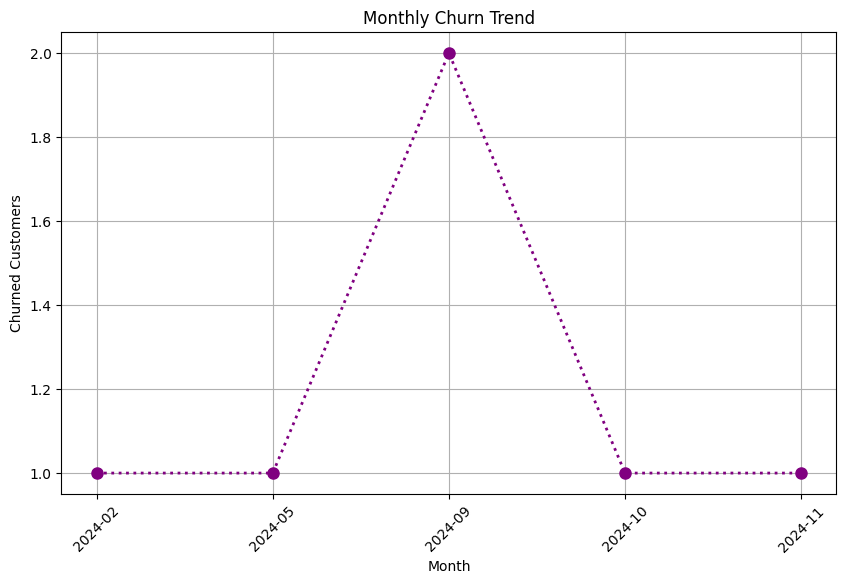

In [87]:
plt.figure(figsize=(10,6))
plt.plot(churn_trend.index.astype(str), churn_trend.values, color='purple', marker='o', linestyle='dotted', linewidth=2, markersize=8)
plt.xticks(rotation=45)
plt.title('Monthly Churn Trend')
plt.xlabel('Month')
plt.ylabel('Churned Customers')
plt.grid(True)
plt.show()


<Figure size 1200x400 with 0 Axes>

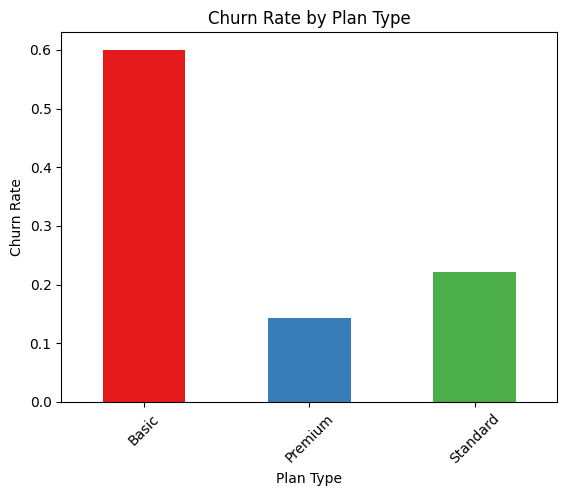

<Figure size 1200x400 with 0 Axes>

In [91]:
#4.2 Churn by Plan type
colors = plt.cm.Set1(np.linspace(0, 1, len(churn_plan)))
visual.groupby('plan_type')['churn_flag'].mean().plot(kind='bar', color=colors)
plt.title('Churn Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45)
plt.figure(figsize=(12, 4))

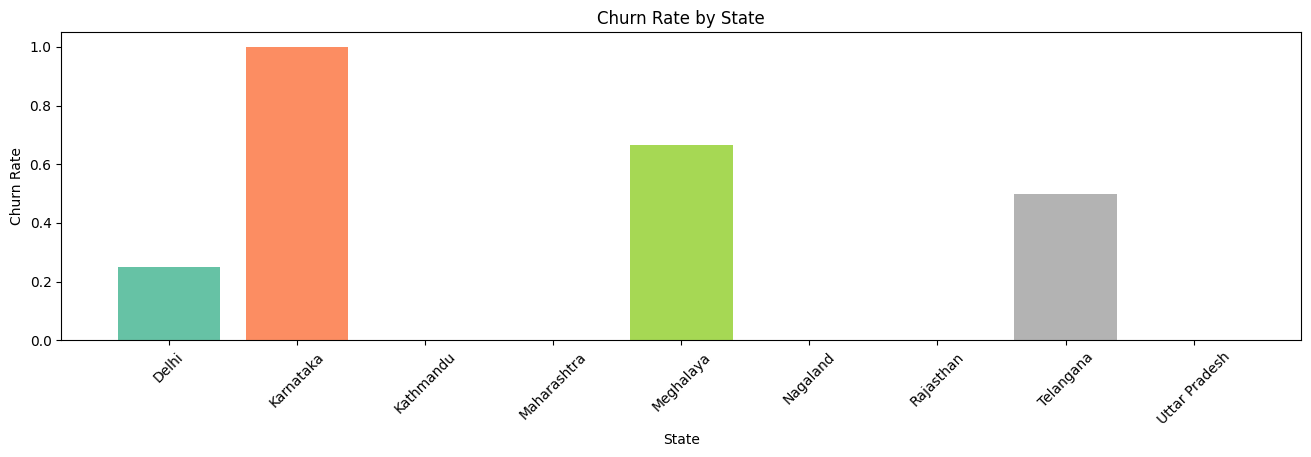

In [93]:
#4.3  Churn by state

churn_plan = visual.groupby('state')['churn_flag'].mean()
colors = plt.cm.Set2(np.linspace(0, 1, len(churn_plan)))

plt.figure(figsize=(16, 4))
plt.bar(churn_plan.index, churn_plan.values, color=colors)
plt.title('Churn Rate by State')
plt.xlabel('State')
plt.ylabel('Churn Rate')
plt.xticks(rotation=45)
plt.show()

# 5. **Visualization using Seaborn**

In [96]:
#encoding - convert str to numeric so that we can find corr b/w features.

visual[['plan_type', 'contract_type', 'churn_risk', 'churn_score', 'churn_flag',  'escalations']].head()

,plan_type,contract_type,churn_risk,churn_score,churn_flag,escalations
0,Standard,Annual,low,12,0,0
1,Premium,Annual,high,91,1,1
2,Basic,Monthly,low,34,0,0
3,Premium,Annual,low,8,0,0
4,Standard,Monthly,high,88,1,1


In [103]:
encoded = visual[['plan_type', 'contract_type', 'churn_risk', 'churn_score', 'churn_flag',  'escalations']]
order_mapping = {
    'plan_type': ['Basic', 'Standard', 'Premium'],
    'contract_type' : ['Monthly', 'Annual'],
    'churn_risk' : ['low','med', 'high']
    }

for col, order in order_mapping.items():
    encoded[col] = pd.Categorical(encoded[col].astype('category'), categories=order, ordered=True).codes
    # encoded[col] = encoded[col].cat.codes
    # encoded[col] = encoded[col].astype('int64')

encoded.head()

,plan_type,contract_type,churn_risk,churn_score,churn_flag,escalations
0,1,1,0,12,0,0
1,2,1,2,91,1,1
2,0,0,0,34,0,0
3,2,1,0,8,0,0
4,1,0,2,88,1,1


In [104]:
visual[['plan_type', 'contract_type', 'churn_risk', 'churn_score', 'churn_flag',  'escalations']].head()

,plan_type,contract_type,churn_risk,churn_score,churn_flag,escalations
0,Standard,Annual,low,12,0,0
1,Premium,Annual,high,91,1,1
2,Basic,Monthly,low,34,0,0
3,Premium,Annual,low,8,0,0
4,Standard,Monthly,high,88,1,1


<Axes: >

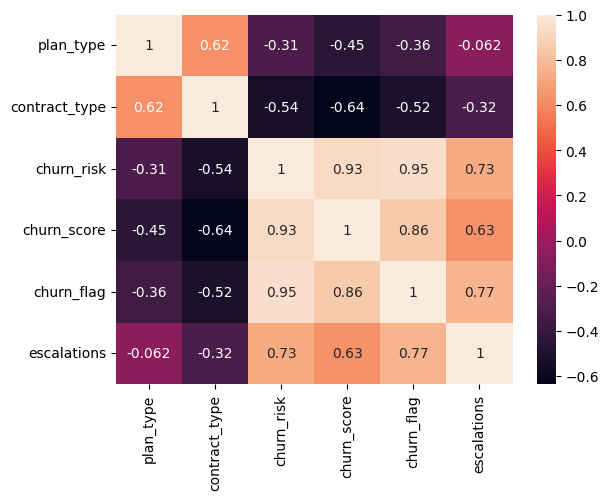

In [105]:
# Heatmap (correlation matrix)

sns.heatmap(encoded.corr(), annot = True)

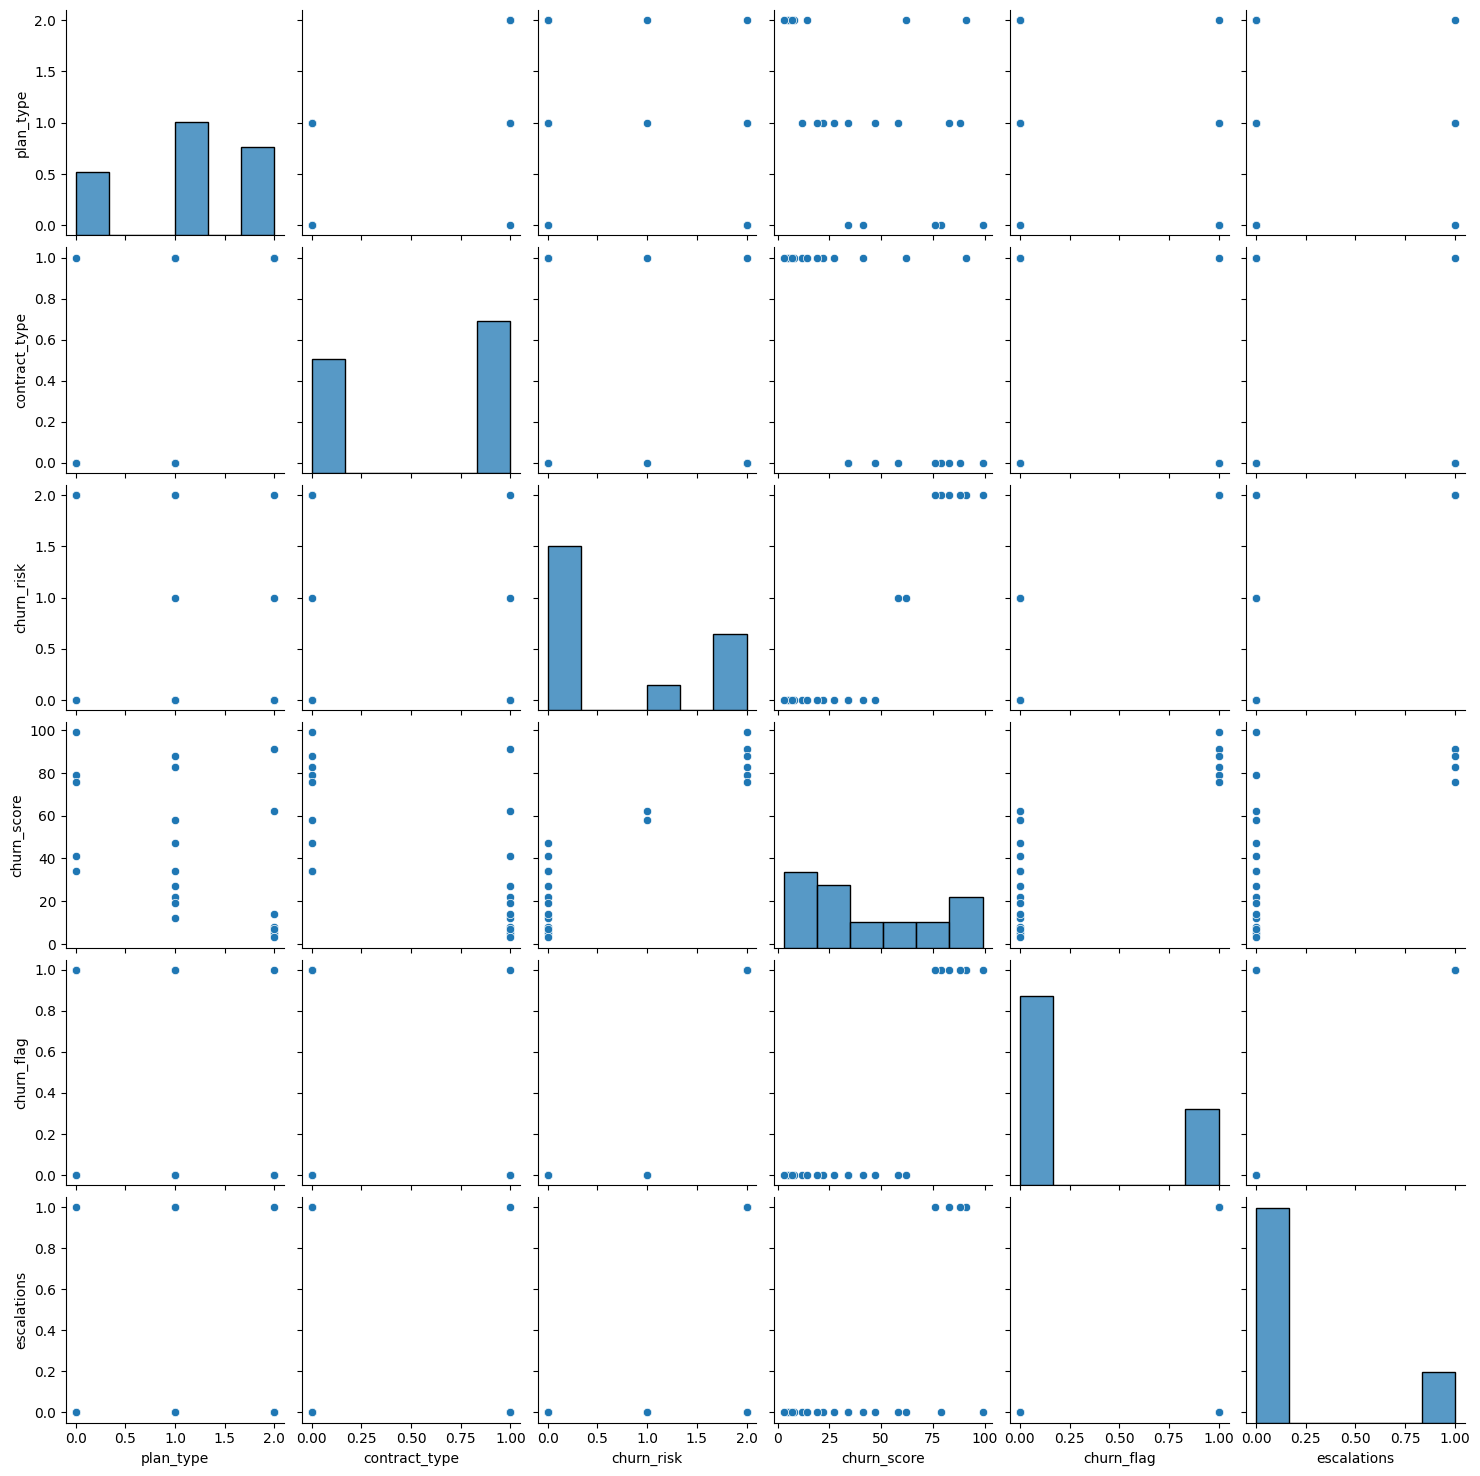

In [106]:
# Pairplot

sns.pairplot(encoded)

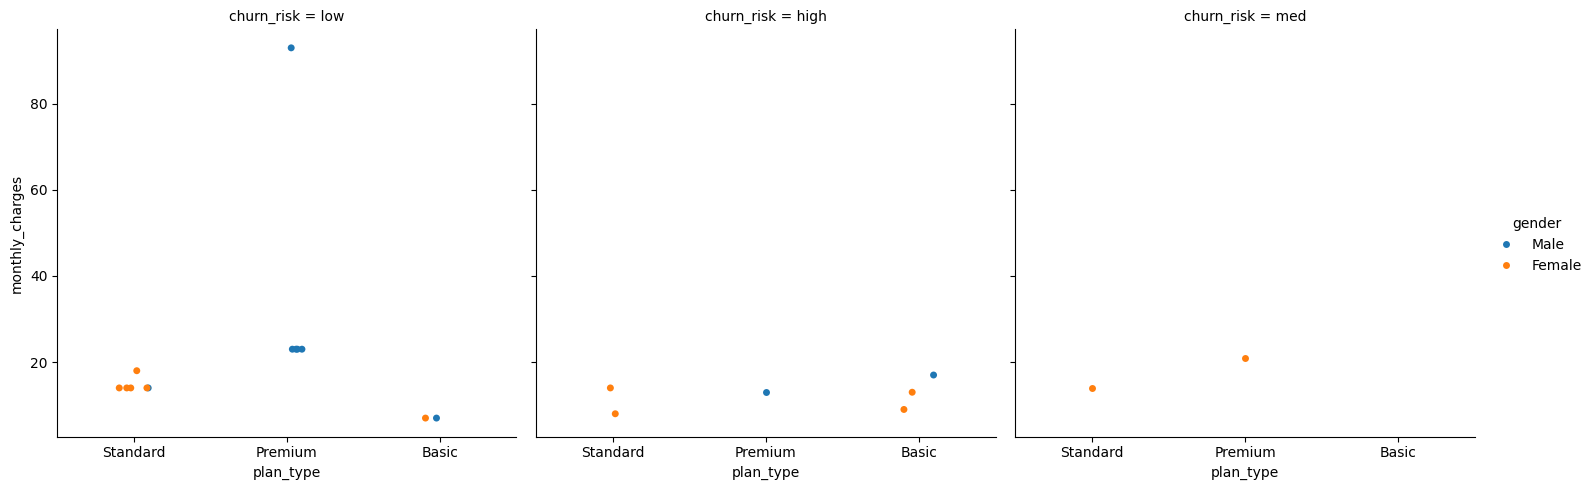

In [107]:
# Catplot / Facegrid plot

sns.catplot(data=visual, x='plan_type', y='monthly_charges', hue='gender', col='churn_risk'
            )

# 6. **Pivot Table**

In [110]:
pd.pivot_table(
    visual,
    index='plan_type',
    values='churn_flag',
    aggfunc='mean'
)

,churn_flag
plan_type,
Basic,0.600000
Premium,0.142857
Standard,0.222222


In [112]:
pd.pivot_table(
    visual,
    index='plan_type',
    values=['monthly_charges', 'customerid', 'churn_flag'],
    aggfunc= {
        'monthly_charges': 'sum',
        'customerid': 'nunique',
        'churn_flag': 'mean'
    }
)

,churn_flag,customerid,monthly_charges
plan_type,,,
Basic,0.600000,5,52.95
Premium,0.142857,7,218.93
Standard,0.222222,9,123.91


# **7. SQl in Python**

In [116]:
# Create db in sql
conn = sqlite3.connect('test_db.sqlite')

#table details
conn.execute('CREATE TABLE users (first_name TEXT, country TEXT, budget INTEGER)')

#commit and save
conn.commit()

#close connection
#conn.close()


OperationalError: table users already exists

In [119]:
# insert data
cursor = conn.cursor()

cursor.execute(
    """
      INSERT INTO users VALUES
        ('Ruby', 'India', 9000),
        ('Ivan', 'Germany', 5500),
        ('Ishan', 'India', 8700)
    """
)

#commit and save
conn.commit()


In [120]:
#Check inset data into table

conn = sqlite3.connect('test_db.sqlite')
query = """SELECT * FROM users"""

df_result = pd.read_sql(query, conn)
df_result.head()

,first_name,country,budget
0,Ruby,india,9000
1,Ivan,Germany,5500
2,Ishan,india,8700
3,Ruby,India,9000
4,Ivan,Germany,5500


In [123]:
#aggregation

query = """
          SELECT count  ry, sum(budget) as total_budget
          FROM users
          GROUP BY country
"""
df_agg = pd.read_sql(query, conn)
df_agg

,country,total_budget
0,Germany,11000
1,India,17700
2,india,17700


In [124]:
#close connection
conn.close()

In [61]:
df.columns

Index(['customerid', 'subscription_start_date', 'subscription_type',
       'renewal_date', 'plan_type', 'contract_type', 'cancellation_date',
       'cancellation_reason', 'monthly_charges', 'cltv', 'churn_score',
       'churn_flag', 'customer_name', 'country', 'state', 'gender', 'dob',
       'complaint_date', 'escalations', 'csat_score', 'complaint_count',
       'tenure_days', 'churn_risk'],
      dtype='object')